In [6]:
import pandas as pd
import numpy as np
import os

In [7]:
os.chdir("C:\\Users\\MEGHNA SINGH\\Downloads")

In [8]:
df = pd.read_csv("spam.csv")

In [9]:
df.sample(5)

,Category,Message
1957,ham,K...k:)why cant you come here and search job:)
3352,ham,At what time are you coming.
580,ham,Arngd marriage is while u r walkin unfortuntly...
880,spam,U have a Secret Admirer who is looking 2 make ...
1669,ham,"Yes..but they said its IT.,"


In [10]:
# renameing the cols
df.rename(columns={'Category':'category','Message':'message'},inplace=True)

In [11]:
df.shape

(5572, 2)

In [12]:
# 1. Data cleaning
# 2. EDA
# 3. Text preprocessing
# 4. Model Building
# 5. Evalution
# 6. Improvement
# 7. Website
# 8. Deploy

##1. Data Cleaning

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5572 non-null   object
 1   message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [15]:
df['category'] = encoder.fit_transform(df['category'])

In [16]:
df.head()

,category,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
# missing values
df.isnull().sum()

category    0
message     0
dtype: int64

In [18]:
# check for duplicate values
df.duplicated().sum()

415

In [19]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [20]:
df.duplicated().sum()

0

In [21]:
df.shape

(5157, 2)

 2. EDA

In [22]:
df.head()

,category,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df['category'].value_counts()

0    4516
1     641
Name: category, dtype: int64

([<matplotlib.patches.Wedge at 0x2bc4f20ee20>,
 [Text(-1.017194586770333, 0.41870654717251754, 'ham'),
  Text(1.0171945769697988, -0.41870657098167496, 'spam')],
 [Text(-0.5548334109656361, 0.22838538936682773, '87.57'),
  Text(0.5548334056198901, -0.22838540235364085, '12.43')])

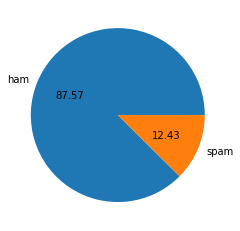

In [24]:
import matplotlib.pyplot as plt
plt.pie(df['category'].value_counts(), labels=['ham','spam'],autopct="%0.2f")

In [25]:
# Data is imbalanced

In [26]:
import nltk

In [27]:
!pip install nltk

In [28]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\MEGHNA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
df['num_characters'] = df['message'].apply(len)

In [30]:
df.head()

,category,message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [31]:
# num of words
df['num_words'] = df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [32]:
df.head()

,category,message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [33]:
df['num_sentences'] = df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [34]:
df.head()

,category,message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [35]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.557882,1.950553
std,58.382922,13.406024,1.362981
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [36]:
# ham
df[df['category'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.264836,1.806244
std,56.708301,13.587852,1.281910
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [37]:
# spam
df[df['category'] == 1][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.967239
std,30.399707,7.103501,1.480241
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,8.000000


In [38]:
import seaborn as sns

<AxesSubplot:xlabel='num_characters', ylabel='Count'>

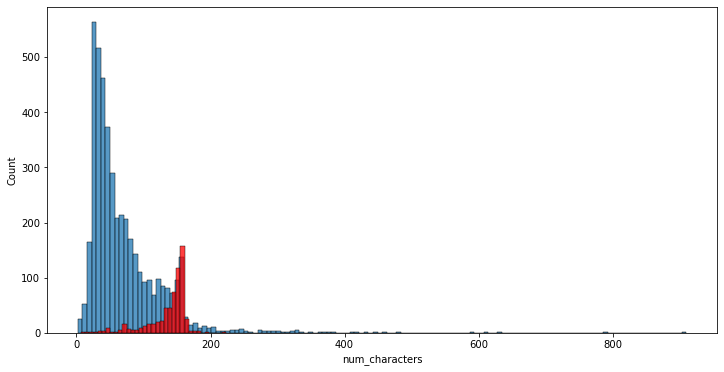

In [39]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['category'] == 0]['num_characters'])
sns.histplot(df[df['category'] == 1]['num_characters'],color='red')


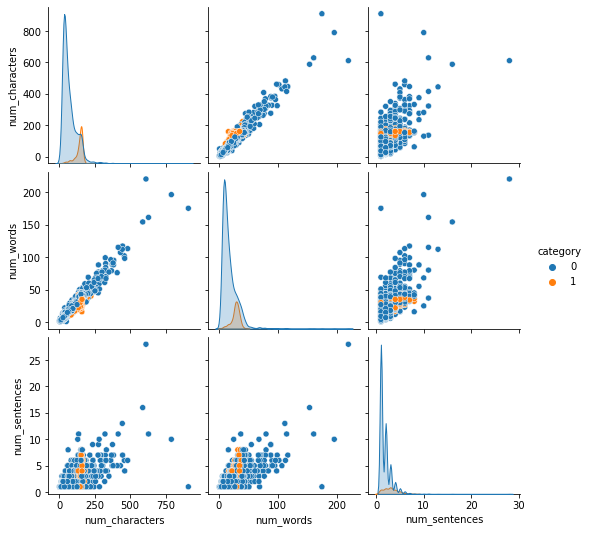

In [40]:
sns.pairplot(df,hue='category')

<AxesSubplot:>

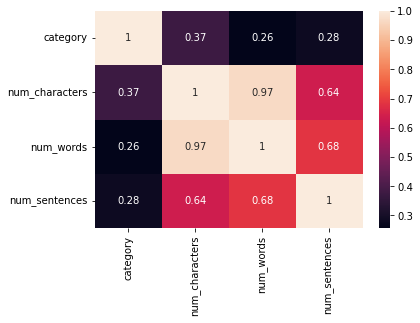

In [41]:
sns.heatmap(df.corr(),annot=True)

# 3.   Data Preprocessing
  .Lower case
  .Tokenization
  .Removing special characters
  .Removing stop words and punctuation
  .Stemming

In [42]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\MEGHNA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\MEGHNA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [43]:
from nltk.corpus import stopwords
import string

In [44]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [45]:
def transform_message(message):
    message = message.lower()
    message = nltk.word_tokenize(message)
    
    y = []
    for i in message:
        if i.isalnum():
            y.append(i)
    message = y[:]
    y.clear
    
    for i in message:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    message = y[:]
    y.clear
    
    for i in message:
            y.append(ps.stem(i))
    return " ".join(y)

In [46]:
transform_message('I loved the YT lectures on Machine Learning. How about you?')

'i loved the yt lectures on machine learning how about you loved yt lectures machine learning i love the yt lectur on machin learn how about you love yt lectur machin learn'

In [47]:
df['message'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [48]:
df['transformed_message'] = df['message'].apply(transform_message)

In [49]:
df.head()

,category,message,num_characters,num_words,num_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni ok lar joking wif u on...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor u c already then say u ...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i do think he goes to usf he lives around ...


In [50]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [51]:

from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white',)

In [52]:
message = (df[df['category'] == 1]['transformed_message'].dropna().str.cat(sep=" "))
spam_wc = wc.generate(message)

ValueError: Only supported for TrueType fonts

In [ ]:
plt.imshow(spam_wc)

In [54]:
spam_corpus = []
for msg in df[df['category'] == 1]['transformed_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [55]:
len(spam_corpus)

47998

C:\Users\MEGHNA SINGH\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


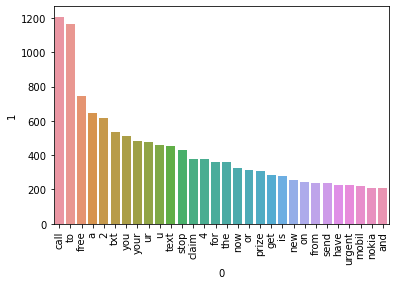

In [56]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()


In [57]:
ham_corpus = []
for msg in df[df['category'] == 0]['transformed_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [58]:
len(ham_corpus)

199052

C:\Users\MEGHNA SINGH\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


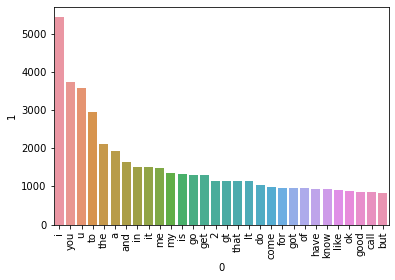

In [59]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[0],pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

# 4. Model Building

In [60]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [61]:
X = tfidf.fit_transform(df['transformed_message']).toarray()

In [62]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [63]:
# appending the num_character col to X
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [64]:
X.shape

(5157, 3001)

In [65]:
y = df['category'].values

In [66]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [69]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [70]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [71]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test) 
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9031007751937985
[[819  86]
 [ 14 113]]
0.5678391959798995


In [72]:
mnb.fit(X_train,y_train)
y_pred2 = gnb.predict(X_test) 
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9031007751937985
[[819  86]
 [ 14 113]]
0.5678391959798995


In [70]:
bnb.fit(X_train,y_train)
y_pred3 = gnb.predict(X_test) 
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9031007751937985
[[819  86]
 [ 14 113]]
0.5678391959798995


In [71]:
# tfidf --> MNB

In [72]:
!pip install xgboost

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [74]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrs = LogisticRegression(solver='liblinear',penalty='l1')
rfc = RandomForestClassifier(n_estimators=50,random_state=2)
abc = AdaBoostClassifier(n_estimators=50,random_state=2)
bc = BaggingClassifier(n_estimators=50,random_state=2)
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [75]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrs,
    'RF' : rfc,
    'AdaBoost' : abc,
    'BgC' : bc,
    'ETC' : etc,
    'GBDT' : gbdt,
    'xgb' : xgb
}

In [76]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [77]:
train_classifier(svc,X_train,y_train,X_test,y_test)

C:\Users\MEGHNA SINGH\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.876937984496124, 0.0)

In [78]:
accuracy_scores = []
precision_scores =[]

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)
    
    print("For",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


C:\Users\MEGHNA SINGH\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


For SVC
Accuracy -  0.876937984496124
Precision -  0.0
For KN
Accuracy -  0.9476744186046512
Precision -  0.8173913043478261
For NB
Accuracy -  0.9544573643410853
Precision -  1.0
For DT
Accuracy -  0.9593023255813954
Precision -  0.9775280898876404
For LR
Accuracy -  0.9680232558139535
Precision -  0.9607843137254902
For RF
Accuracy -  0.9738372093023255
Precision -  0.9901960784313726
For AdaBoost
Accuracy -  0.9718992248062015
Precision -  0.9224137931034483
For BgC
Accuracy -  0.9718992248062015
Precision -  0.9711538461538461
For ETC
Accuracy -  0.9757751937984496
Precision -  0.9811320754716981
For GBDT
Accuracy -  0.9631782945736435
Precision -  0.989010989010989
For xgb
Accuracy -  0.9806201550387597
Precision -  1.0


In [79]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [80]:
performance_df

,Algorithm,Accuracy,Precision
2,NB,0.954457,1.000000
10,xgb,0.980620,1.000000
5,RF,0.973837,0.990196
9,GBDT,0.963178,0.989011
8,ETC,0.975775,0.981132
3,DT,0.959302,0.977528
7,BgC,0.971899,0.971154
4,LR,0.968023,0.960784
6,AdaBoost,0.971899,0.922414
1,KN,0.947674,0.817391


In [81]:
performance_df1 = pd.melt(performance_df, id_vars = 'Algorithm')

In [82]:
performance_df1

,Algorithm,variable,value
0,NB,Accuracy,0.954457
1,xgb,Accuracy,0.980620
2,RF,Accuracy,0.973837
3,GBDT,Accuracy,0.963178
4,ETC,Accuracy,0.975775
5,DT,Accuracy,0.959302
6,BgC,Accuracy,0.971899
7,LR,Accuracy,0.968023
8,AdaBoost,Accuracy,0.971899
9,KN,Accuracy,0.947674


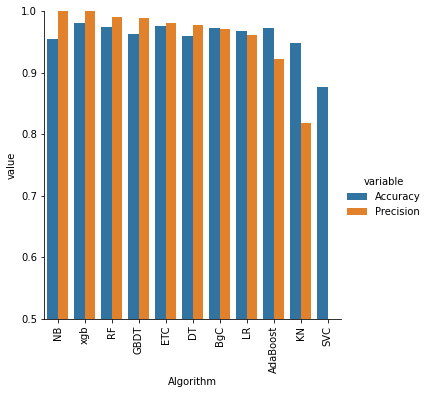

In [83]:
sns.catplot(x = 'Algorithm',y='value',
           hue = 'variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [84]:
# Model improve
# 1. Change the max_features parameter of Tfidf

In [85]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_fit_3000':accuracy_scores,'Precision_max_fit_3000':precision_scores})

In [86]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores})

In [87]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [88]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [89]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_scores':precision_scores}).sort_values('Precision_num_scores',ascending=False)

In [90]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_scores
0,NB,0.954457,1.000000,0.954457,1.000000,0.954457,1.000000,0.954457,1.000000
1,xgb,0.980620,1.000000,0.980620,1.000000,0.980620,1.000000,0.980620,1.000000
2,RF,0.973837,0.990196,0.973837,0.990196,0.973837,0.990196,0.973837,0.990196
3,GBDT,0.963178,0.989011,0.963178,0.989011,0.963178,0.989011,0.963178,0.989011
4,ETC,0.975775,0.981132,0.975775,0.981132,0.975775,0.981132,0.975775,0.981132
5,DT,0.959302,0.977528,0.959302,0.977528,0.959302,0.977528,0.959302,0.977528
6,BgC,0.971899,0.971154,0.971899,0.971154,0.971899,0.971154,0.971899,0.971154
7,LR,0.968023,0.960784,0.968023,0.960784,0.968023,0.960784,0.968023,0.960784
8,AdaBoost,0.971899,0.922414,0.971899,0.922414,0.971899,0.922414,0.971899,0.922414
9,KN,0.947674,0.817391,0.947674,0.817391,0.947674,0.817391,0.947674,0.817391


In [91]:
# Voting Classifier
svc = SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)

from sklearn.ensemble import VotingClassifier

In [92]:
voting = VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [93]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [94]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
                    

Accuracy 0.9496124031007752
Precision 1.0


In [95]:
# Applying stacking
estimators=[('svm',svc),('nb',mnb),('et',etc)]
final_estimator=RandomForestClassifier()

In [96]:
from sklearn.ensemble import StackingClassifier

In [97]:
clf = StackingClassifier(estimators=estimators,final_estimator=final_estimator)

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

In [73]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))                       